# Building a Hybrid Image Retrieval System

In this notebook, we will build a hybrid image retrieval system using OpenAI's CLIP (Contrastive Language-Image Pre-training) model. This system will allow us to search for similar images based on a combination of a source image and a text query.

## 1. Data Setup

This section focuses on preparing the CelebA dataset for retrieval. We will mount Google Drive, unzip the dataset, and load it into memory. REMEMBER TO MAKE A COPY OF DATASET FOLDER, WHICH WAS PROVIDED ON MOODLE, TO YOUR PERSONAL GOOGLE DRIVE

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!mkdir -p /content/datasets

Unzip the CelebA dataset into the `/content/datasets` folder. This process may take 1-2 minutes.

In [3]:
# This should take 1-2 minutes
# It unzips the dataset in the runtime's local SSD, so when
# you disconnect, it gets deleted
!unzip -q /content/drive/MyDrive/datasets/celeba.zip -d /content/datasets/

Load the CelebA dataset using the `torchvision.datasets` library.

In [4]:
import torch
from pathlib import Path

from torchvision.datasets import CelebA

In [5]:
# Do *not* put `celeba` in the path.
# The dataset class will do that automatically!
data_root = Path("/content/datasets")

In [6]:
celeba = CelebA(root=data_root, split="test", download=False)

Check the number of images in the test dataset.

In [7]:
# This should be 19,962
len(celeba)

19962

## 2. Model Loading and Embedding Setup

In this section, we will load the CLIP model from Hugging Face and prepare functions to create embeddings for images from the CelebA dataset.

In [8]:
from PIL import Image
from tqdm import tqdm

from transformers import CLIPProcessor, CLIPModel
import torch # Ensure torch is imported

# Device setup
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load the CLIP model and processor from Hugging Face
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)

print(f"CLIP model (Hugging Face) loaded and using device: {device}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIP model (Hugging Face) loaded and using device: cuda


Define a function to create image embeddings in batches for increased efficiency.

In [9]:
def embed_images_batched(dataset, model, processor, batch_size=32, device='cuda'):
    all_embeddings = []

    # Define a custom collate function to handle PIL images and apply the processor
    def custom_collate_fn(batch):
        # 'batch' is a list of samples from the dataset.
        # For CelebA, each sample is (PIL_image, attribute_tensor).
        images_pil = [item[0] for item in batch] # Extract PIL images

        # Process the PIL images using the Hugging Face CLIPProcessor
        # This returns a dictionary with 'pixel_values' (and potentially 'attention_mask')
        inputs = processor(images=images_pil, return_tensors="pt", padding=True)
        return inputs # The DataLoader will now yield this dictionary

    data_loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2, # Keep num_workers for speed, as collate_fn handles PIL images now
        collate_fn=custom_collate_fn # Pass the custom collate function
    )

    model.eval()
    with torch.no_grad():
        for batch_inputs in tqdm(data_loader, desc="Embedding images"):
            # 'batch_inputs' is now the dictionary returned by custom_collate_fn
            # Move the tensors in the dictionary to the appropriate device
            batch_inputs = {k: v.to(device) for k, v in batch_inputs.items()}

            # Generate embeddings
            image_features = model.get_image_features(**batch_inputs)
            # Extract the actual tensor from BaseModelOutputWithPooling
            all_embeddings.append(image_features.pooler_output)

    return torch.cat(all_embeddings).cpu()

Now, let's create embeddings for the entire CelebA test set. This process might take a few minutes.

In [10]:
celeba_embeddings = embed_images_batched(celeba, model, processor, batch_size=64, device=device)
print(f"Shape of CelebA embeddings: {celeba_embeddings.shape}")


Embedding images: 100%|██████████| 312/312 [01:08<00:00,  4.53it/s]

Shape of CelebA embeddings: torch.Size([19962, 512])


## 3. Inference and Retrieval Logic

This section defines the core functions to calculate similarity and perform retrieval of top images based on embeddings.

The `retrieve_top_k_cosine` function calculates the cosine similarity between the query embedding and all other embeddings, then returns the indices of the most similar images.

In [11]:
import torch.nn.functional as F

def retrieve_top_k_cosine(query_embedding, all_embeddings, k=5):
    # Normalize embeddings for cosine similarity
    query_embedding_norm = F.normalize(query_embedding, p=2, dim=-1)
    all_embeddings_norm = F.normalize(all_embeddings, p=2, dim=-1)

    # Calculate cosine similarity
    # (N, D) @ (D, M) -> (N, M) if all_embeddings_norm is transposed
    # Here, query_embedding is (1, D) and all_embeddings is (M, D)
    similarities = (query_embedding_norm @ all_embeddings_norm.T).squeeze(0)

    # Get top k indices
    top_k_values, top_k_indices = torch.topk(similarities, k=k)

    return top_k_indices.tolist()

The `perform_retrieval` function takes a source image index and a text query, then uses the CLIP model to create a combined embedding and find the most similar images.

In [12]:
def perform_retrieval(source_image_idx, text_query, celeba_dataset, celeba_embeddings, model, processor, device, k=5):
    # 1. Embed source image
    source_image_pil = celeba_dataset[source_image_idx][0] # Get PIL image from dataset
    image_inputs = processor(images=source_image_pil, return_tensors="pt").to(device)
    with torch.no_grad():
        image_feature = model.get_image_features(**image_inputs)

    # 2. Embed text query
    text_inputs = processor(text=[text_query], return_tensors="pt", padding=True, truncation=True).to(device)
    with torch.no_grad():
        text_feature = model.get_text_features(**text_inputs)

    # 3. Combine embeddings (e.g., by summing or concatenating and passing through a layer)
    # For simplicity, let's sum them for now. More advanced combination might be needed.
    # Note: CLIP features are typically normalized, summing them is a basic way to combine.
    combined_query_embedding = (image_feature.pooler_output + text_feature.pooler_output) / 2 # Simple average

    # Ensure celeba_embeddings is on the correct device for similarity calculation
    device_celeba_embeddings = celeba_embeddings.to(device)

    # 4. Retrieve top K similar images from the celeba_embeddings space
    retrieved_indices = retrieve_top_k_cosine(combined_query_embedding, device_celeba_embeddings, k=k)

    return retrieved_indices

Example of using the `perform_retrieval` function with a source image and a text query.

In [13]:
perform_retrieval(13, "+smile", celeba, celeba_embeddings, model, processor, device)

[13, 13877, 11778, 12104, 4650]

Display a retrieved image.

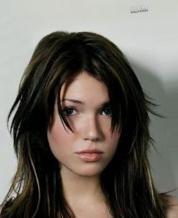

In [14]:
celeba[13][0]

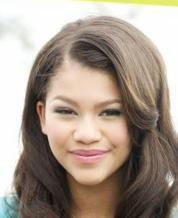

In [15]:
celeba[13877][0]

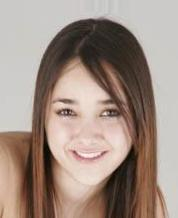

In [16]:
celeba[4650][0]

## 4. Evaluation Metrics

This section defines the `evaluate_retrieval` function to measure the performance of the retrieval system based on Recall@K and Precision@K metrics.

In [17]:
def evaluate_retrieval(
    retrieved_indices: list[int],
    ground_truth_indices: list[int],
    k: int
):
    """
    Evaluate the retrieval performance for a single source image.

    Args:
    ----
        retrieved_indices: list of image IDs predicted by the model,
            ordered by similarity (descending).
        ground_truth_indices: list of valid target IDs from the benchmark JSON.
        k: the cutoff for top-K evaluation (e.g., 1, 5, 10).

    Return:
    ------
        A dictionary containing Recall@K and Precision@K.

    """
    # Isolate the top K predictions
    top_k_retrieved = retrieved_indices[:k]

    # Calculate the intersection between predictions and ground truth
    hits = set(top_k_retrieved).intersection(set(ground_truth_indices))
    num_hits = len(hits)

    # Metrics calculations
    # Recall@K (Hit Rate): 1 if at least one match is found, 0 otherwise
    recall_at_k = 1 if num_hits > 0 else 0

    # Precision@K: Fraction of top K predictions that are correct
    precision_at_k = num_hits / k

    return {
        f"Recall@{k}": recall_at_k,
        f"Precision@{k}": precision_at_k
    }

Example of using the `evaluate_retrieval` function.

In [18]:
# --- Example Usage ---
# Suppose the model returns these indices from most to least similar:
predictions = [1, 2, 3, 4, 5]
# And we load this from our JSON for this specific source:
ground_truth = [3, 2, 1]

# Evaluate at K=1 and K=5
print("Results @ 1:", evaluate_retrieval(predictions, ground_truth, k=1))
print("Results @ 5:", evaluate_retrieval(predictions, ground_truth, k=5))

Results @ 1: {'Recall@1': 1, 'Precision@1': 1.0}
Results @ 5: {'Recall@5': 1, 'Precision@5': 0.6}


## 5. Loading and Visualizing Annotations (Ground Truth)

This section will load the annotations for evaluation and visualize examples of source images and ground truth matches.

In [19]:
import json
from pathlib import Path


In [20]:
annotations_path = Path("/content/drive/MyDrive/datasets/celeba_evaluation.json")

with open(annotations_path, "r") as f:
    annotations = json.load(f)

len(annotations)

14

Structure of the `annotations` variable:

In [21]:
# `annotations` is a list of queries
# Each query is a dictionary with these keys:
# - `query`: the textual query itself
# - `ground_truth`: a dictionary of images
#
# Each element in `ground_truth` is structured as:
# {
#    idx: list[int]
# }
# `idx` is the source image that you have to use together with the `query`
# `list[int]` is the list of acceptable target images, i.e., the images
# that you should retrieve

print(annotations[0].keys())
print()
print("Query:", annotations[0]["query"])
print("Source images:", len(annotations[0]["ground_truth"].keys()))

dict_keys(['query', 'ground_truth'])

Query: +Smiling
Source images: 4786


Let's test the evaluation function by simulating retrieval for a first query/image.

In [22]:
print("Nothing retrieved:\n", evaluate_retrieval([], annotations[0]["ground_truth"]["13"], 1))
print()
print("Retrieved only one wrong image:\n", evaluate_retrieval([0], annotations[0]["ground_truth"]["13"], 1))
print()
print("Retrieved 10 correct images:\n", evaluate_retrieval(annotations[0]["ground_truth"]["13"][:10], annotations[0]["ground_truth"]["13"], 1))
print()
# This returns 0 and 0 because top-k is set to 1, and the first 5 images
# (by highest similarity) are incorrect. We need to jump at least to top-6 here!
print("Retrieved 5 correct images and 5 wrong images:\n", evaluate_retrieval([0, 1, 2, 3, 4] + annotations[0]["ground_truth"]["13"][:5], annotations[0]["ground_truth"]["13"], 1))
print("Retrieved 5 correct images and 5 wrong images:\n", evaluate_retrieval([0, 1, 2, 3, 4] + annotations[0]["ground_truth"]["13"][:5], annotations[0]["ground_truth"]["13"], 6))

Nothing retrieved:
 {'Recall@1': 0, 'Precision@1': 0.0}

Retrieved only one wrong image:
 {'Recall@1': 0, 'Precision@1': 0.0}

Retrieved 10 correct images:
 {'Recall@1': 1, 'Precision@1': 1.0}

Retrieved 5 correct images and 5 wrong images:
 {'Recall@1': 0, 'Precision@1': 0.0}
Retrieved 5 correct images and 5 wrong images:
 {'Recall@6': 1, 'Precision@6': 0.16666666666666666}


Display the source image and a few of the first ground truth matches.

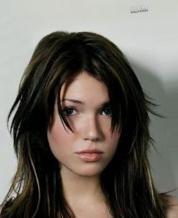

In [23]:
# This is our source image
# Basically, the `key` in the provided JSON corresponds to the
# image index. Note, however, that the key is in string format,
# so remember to convert it with `int(key)`!
celeba[13][0]

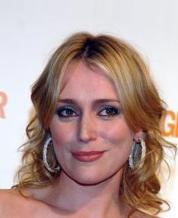

In [24]:
# This is one of the accepted matches
celeba[annotations[0]["ground_truth"]["13"][0]][0]

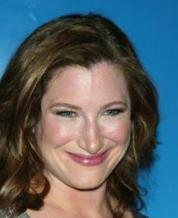

In [25]:
# This is another one of the accepted matches
celeba[annotations[0]["ground_truth"]["13"][1]][0]

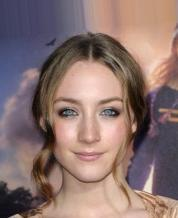

In [26]:
# And yet another one of the accepted matches
celeba[annotations[0]["ground_truth"]["13"][2]][0]

As you can see, all these images are quite similar to the first (source) image. This is exactly what we want. The ground truth was constructed by taking images that match the given query, with a maximum Hamming distance of 2 from the source (meaning perfect matches for the query are not always possible, so we also allow for some minor variations in other attributes).

## 6. Complete Evaluation Pipeline

This section defines a function to perform a comprehensive evaluation across all queries and source images in the annotation set, and then demonstrates its usage and result analysis.

In [27]:
def evaluate_all_queries(
    annotations: list[dict],
    celeba_dataset,
    celeba_embeddings,
    model,
    processor,
    device,
    k_value: int = 5
):
    """
    Evaluates retrieval performance across all queries and source images in the annotations.

    Args:
    -----
        annotations: A list of annotation dictionaries.
        celeba_dataset: The CelebA dataset object.
        celeba_embeddings: Pre-computed embeddings for all CelebA images.
        model: The CLIP model.
        processor: The CLIP processor.
        device: The device to run computations on (e.g., 'cuda' or 'cpu').
        k_value: The cutoff for top-K evaluation.

    Returns:
    --------
        A list of dictionaries, where each dictionary contains results for a single
        (query, source_image) pair.
    """
    all_evaluation_results = []

    # Move celeba_embeddings to the target device once before the loops
    # to prevent repeated transfers and potential out-of-memory errors.
    device_celeba_embeddings = celeba_embeddings.to(device)

    # This outer loop iterates through each unique text query.
    # In your dataset, there are 14 such queries.
    for query_data in tqdm(annotations, desc="Evaluating queries"):
        text_query = query_data["query"]
        ground_truth_for_query = query_data["ground_truth"]

        # This inner loop iterates through each source image associated with the current query.
        # For each query, there can be thousands of source images (e.g., the first query has 4786 source images).
        # The `perform_retrieval` function is called for *each* (query, source_image) pair.
        # This leads to tens of thousands of individual retrieval operations for the full dataset.
        for source_image_id_str, gt_indices_for_source in tqdm(
            ground_truth_for_query.items(),
            desc=f"  Query: '{text_query}'"
        ):
            source_image_idx = int(source_image_id_str)

            # Perform retrieval
            # Pass the already device-moved embeddings to avoid repeated transfers
            retrieved_indices = perform_retrieval(
                source_image_idx,
                text_query,
                celeba_dataset,
                device_celeba_embeddings, # Use the device-moved embeddings
                model,
                processor,
                device,
                k=k_value
            )

            # Evaluate the retrieval
            evaluation_results = evaluate_retrieval(
                retrieved_indices,
                gt_indices_for_source,
                k=k_value
            )

            all_evaluation_results.append({
                "query": text_query,
                "source_image_idx": source_image_idx,
                "retrieved_indices": retrieved_indices,
                "ground_truth_indices": gt_indices_for_source,
                **evaluation_results # Unpack Recall@K and Precision@K
            })

    return all_evaluation_results

Example of using the full evaluation function. Note: Running this function on the entire dataset might take a long time. You can uncomment it to run if needed. DON'T RUN THIS evaluate_all_queries FUNCTION BECAUSE IT TAKES SO LONG AND CAUSES RAM CRASH

In [28]:
# # Example usage of the evaluation function
# # This might take a long time as it iterates through all queries and source images.
# # For demonstration, you might want to run this on a smaller subset of annotations.

# results = evaluate_all_queries(
#     annotations,
#     celeba,
#     celeba_embeddings,
#     model,
#     processor,
#     device,
#     k_value=10
# )

# print(f"Total evaluations performed: {len(results)}")
# # You can then process 'results' to get average metrics, e.g.:
# # avg_recall = sum(r[f'Recall@{k_value}'] for r in results) / len(results)
# # avg_precision = sum(r[f'Precision@{k_value}'] for r in results) / len(results)
# # print(f"Average Recall@{k_value}: {avg_recall:.4f}")
# # print(f"Average Precision@{k_value}: {avg_precision:.4f}")

Evaluate retrieval performance for a sample query.

In [29]:
# Get the first query from annotations (you can change the index to evaluate a different query)
first_query_data = annotations[0]
text_query = first_query_data["query"]

all_evaluation_results_for_this_query = []
k_value = 20 # Evaluate top 20 results

# Iterate through all source images for this single query
# The 'ground_truth' for a query is a dictionary where keys are source image IDs (as strings)
# and values are lists of ground truth target image IDs.
for source_image_id_str, ground_truth_indices in tqdm(
    first_query_data["ground_truth"].items(),
    desc=f"Evaluating all sources for query: '{text_query}'"
):
    source_image_idx = int(source_image_id_str)

    # Perform retrieval for this query and current source image
    retrieved_indices = perform_retrieval(
        source_image_idx,
        text_query,
        celeba,
        celeba_embeddings,
        model,
        processor,
        device,
        k=k_value
    )

    # Evaluate the retrieval using the pre-defined metric
    evaluation_results = evaluate_retrieval(
        retrieved_indices,
        ground_truth_indices,
        k=k_value
    )

    all_evaluation_results_for_this_query.append(evaluation_results)

print(f"\n--- Evaluation Summary for Query: '{text_query}' ---")
print(f"Total source images evaluated for this query: {len(all_evaluation_results_for_this_query)}")

if all_evaluation_results_for_this_query:
    # Calculate average Recall@K and Precision@K
    avg_recall_at_k = sum(res[f"Recall@{k_value}"] for res in all_evaluation_results_for_this_query) / len(all_evaluation_results_for_this_query)
    avg_precision_at_k = sum(res[f"Precision@{k_value}"] for res in all_evaluation_results_for_this_query) / len(all_evaluation_results_for_this_query)

    print(f"Average Recall@{k_value}: {avg_recall_at_k:.4f}")
    print(f"Average Precision@{k_value}: {avg_precision_at_k:.4f}")
else:
    print("No evaluation results were collected for this query.")

Evaluating all sources for query: '+Smiling': 100%|██████████| 4786/4786 [02:37<00:00, 30.41it/s]


--- Evaluation Summary for Query: '+Smiling' ---
Total source images evaluated for this query: 4786
Average Recall@20: 0.3291
Average Precision@20: 0.0296


## 7. Miscellaneous Utilities

This section contains additional useful code snippets, such as attribute index mapping.

In [30]:
# Assign a unique index to each attribute, and get the inverse mapping
idx2attribute = {idx: name for idx, name in enumerate(celeba.attr_names)}
attribute2idx = {name: idx for idx, name in enumerate(celeba.attr_names)}